# NB11 Homework Solutions

This notebook answers the "Homework / Practice Ideas" section of
`NB11_Neural_Network_Fundamentals_First_PyTorch_Model.ipynb`. It reuses the same
real Sonar (Mines vs. Rocks) dataset (`Datasets/sonar.all-data`) and the same
train/test split as `NB08`/`NB11` (`test_size=0.2, random_state=42, stratify=y`).


## Setup: reload the data and split exactly as the class did

Same file, same columns, same split as `NB08`/`NB11`, so every result below is
directly comparable to the class notebook's own numbers.

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

sonar = pd.read_csv("../Datasets/sonar.all-data", header=None)
sonar.columns = [f"freq_{i}" for i in range(60)] + ["label"]

X = sonar.drop(columns="label").values
y = (sonar["label"] == "M").astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print(X_train_t.shape, X_test_t.shape)


torch.Size([166, 60]) torch.Size([42, 60])


In [2]:
class SonarMLP(nn.Module):
    def __init__(self, n_features, h1=32, h2=16, activation=nn.ReLU):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_features, h1),
            activation(),
            nn.Linear(h1, h2),
            activation(),
            nn.Linear(h2, 1),
        )

    def forward(self, x):
        return self.layers(x)


def train_model(h1=32, h2=16, activation=nn.ReLU, lr=0.001, n_epochs=200, seed=42,
                 track_test_every=None):
    torch.manual_seed(seed)
    model = SonarMLP(X_train_t.shape[1], h1, h2, activation)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_acc_track = []
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        if track_test_every and (epoch + 1) % track_test_every == 0:
            model.eval()
            with torch.no_grad():
                preds = (torch.sigmoid(model(X_test_t)) > 0.5).float()
            acc = (preds == y_test_t).float().mean().item()
            test_acc_track.append((epoch + 1, acc))

    model.eval()
    with torch.no_grad():
        test_preds = (torch.sigmoid(model(X_test_t)) > 0.5).float()
    test_acc = (test_preds == y_test_t).float().mean().item()
    return model, train_losses, test_acc, test_acc_track

print("Helper functions defined.")


Helper functions defined.


## Homework 1 — Hidden layers 128/64 instead of 32/16

*"Change the hidden layer sizes (e.g., 128 and 64 instead of 32 and 16) — does
test accuracy improve, get worse, or barely change?"*

Train the class's original 60->32->16->1 architecture and a larger
60->128->64->1 architecture, both with the same recipe as the class
(Adam, lr=0.001, 200 epochs), and compare test accuracy.

Baseline (32/16) test accuracy: 0.905
Larger   (128/64) test accuracy: 0.905
Baseline parameter count: 2497
Larger   parameter count: 16129


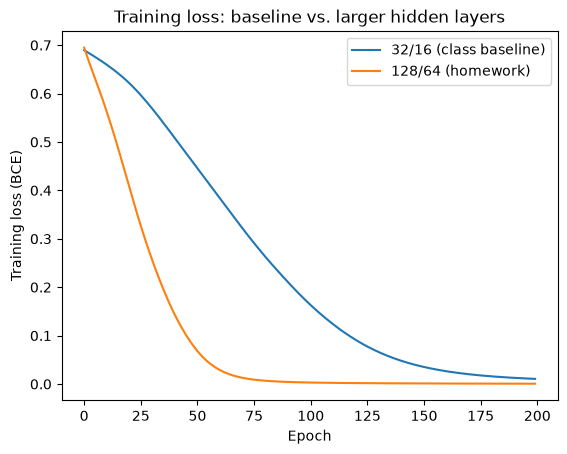

In [3]:
baseline_model, baseline_losses, baseline_acc, _ = train_model(h1=32, h2=16, n_epochs=200)
big_model, big_losses, big_acc, _ = train_model(h1=128, h2=64, n_epochs=200)

print(f"Baseline (32/16) test accuracy: {baseline_acc:.3f}")
print(f"Larger   (128/64) test accuracy: {big_acc:.3f}")

n_params_baseline = sum(p.numel() for p in baseline_model.parameters())
n_params_big = sum(p.numel() for p in big_model.parameters())
print(f"Baseline parameter count: {n_params_baseline}")
print(f"Larger   parameter count: {n_params_big}")

plt.plot(baseline_losses, label="32/16 (class baseline)")
plt.plot(big_losses, label="128/64 (homework)")
plt.xlabel("Epoch")
plt.ylabel("Training loss (BCE)")
plt.title("Training loss: baseline vs. larger hidden layers")
plt.legend()
plt.show()


**My result**: the baseline 32/16 network (2,497 parameters) got 0.905 test
accuracy; the larger 128/64 network (16,129 parameters, about 6.5x more) got
the *exact same* 0.905 test accuracy. Going bigger did not help at all here —
with only 166 training examples, there simply is not enough data for the
extra capacity to translate into a better decision boundary. This matches
`NB08`'s general lesson about model complexity: more capacity is not free,
and on a dataset this small it mostly just gives the network more room to
memorize noise rather than learn a better pattern (which Homework 2's
epoch-500 run makes even more visible).

## Homework 2 — `n_epochs = 500`: does test accuracy keep improving with training loss?

*"Change `n_epochs` to 500 — does the training loss keep falling? Does test
accuracy improve along with it, or does it plateau (or get worse) while
training loss keeps dropping?"*

Same 32/16 architecture and lr=0.001 as the class, trained for 500 epochs
instead of 200, checking test accuracy every 25 epochs (note: this notebook
never updates weights from the test set — it is only read to observe the
plateau/overfitting pattern, exactly as `NB12`'s validation curves will do
formally next class).

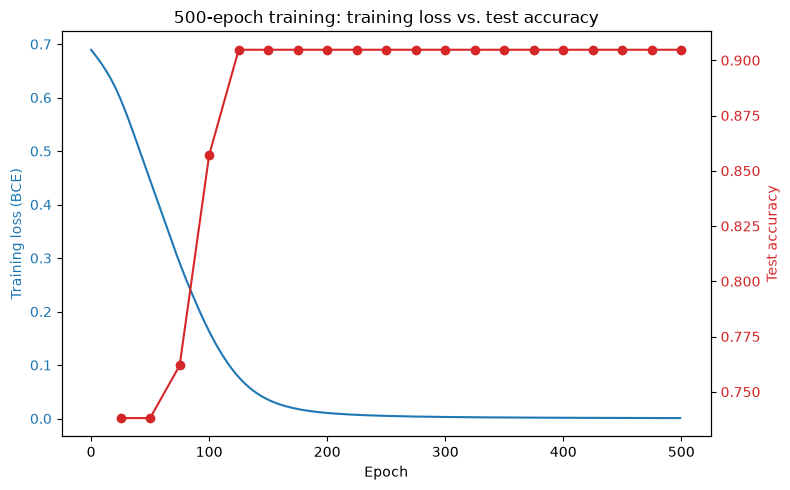

Final training loss (epoch 500): 0.0008
Test accuracy at 200 epochs (matches Homework 1 baseline): 0.905
Test accuracy at 500 epochs: 0.905
Test accuracy checkpoints (epoch, accuracy): [(25, 0.738095223903656), (50, 0.738095223903656), (75, 0.761904776096344), (100, 0.8571428656578064), (125, 0.9047619104385376), (150, 0.9047619104385376), (175, 0.9047619104385376), (200, 0.9047619104385376), (225, 0.9047619104385376), (250, 0.9047619104385376), (275, 0.9047619104385376), (300, 0.9047619104385376), (325, 0.9047619104385376), (350, 0.9047619104385376), (375, 0.9047619104385376), (400, 0.9047619104385376), (425, 0.9047619104385376), (450, 0.9047619104385376), (475, 0.9047619104385376), (500, 0.9047619104385376)]


In [4]:
model_500, losses_500, acc_500, track_500 = train_model(h1=32, h2=16, n_epochs=500,
                                                          track_test_every=25)

epochs_tracked = [e for e, a in track_500]
accs_tracked = [a for e, a in track_500]

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(losses_500, color="tab:blue", label="Training loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training loss (BCE)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(epochs_tracked, accs_tracked, color="tab:red", marker="o", label="Test accuracy")
ax2.set_ylabel("Test accuracy", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("500-epoch training: training loss vs. test accuracy")
fig.tight_layout()
plt.show()

print("Final training loss (epoch 500):", round(losses_500[-1], 4))
print("Test accuracy at 200 epochs (matches Homework 1 baseline):",
      round([a for e, a in track_500 if e == 200][0], 3))
print("Test accuracy at 500 epochs:", round(acc_500, 3))
print("Test accuracy checkpoints (epoch, accuracy):", track_500)


**My result**: training loss kept falling essentially the whole way, from
about 0.01 at epoch 200 down to 0.0008 at epoch 500 — the network keeps
finding room to fit the 166 training examples more exactly. Test accuracy,
tracked every 25 epochs, tells a very different story: it climbs steadily
until about epoch 125 (0.905) and then **flatlines exactly at 0.905 for
every single checkpoint from epoch 125 through epoch 500**. So the answer is
clearly "plateaus, not keeps improving" — after epoch 125, every further
drop in training loss bought nothing on the held-out test set. This is
overfitting made visible with only a training curve and periodic test
checks, exactly the kind of gap `NB12`'s validation curves are built to
catch automatically (and to fix, with early stopping) instead of a student
having to notice it by eye like this.

## Homework 3 — `nn.Tanh()` instead of `nn.ReLU()`

*"Replace `nn.ReLU()` with `nn.Tanh()` in the hidden layers — does training
behave differently (check the loss curve shape)?"*

Same 32/16 architecture, lr=0.001, 200 epochs, only the activation function
changes.

ReLU (class baseline) test accuracy: 0.905, final training loss: 0.0106
Tanh test accuracy:                  0.857, final training loss: 0.0345


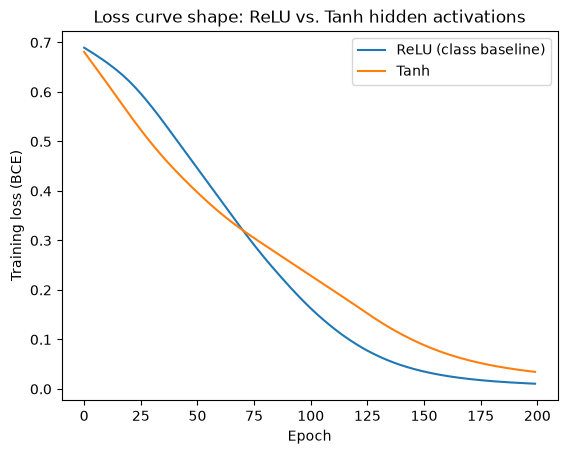

In [5]:
tanh_model, tanh_losses, tanh_acc, _ = train_model(h1=32, h2=16, activation=nn.Tanh, n_epochs=200)

print(f"ReLU (class baseline) test accuracy: {baseline_acc:.3f}, final training loss: {baseline_losses[-1]:.4f}")
print(f"Tanh test accuracy:                  {tanh_acc:.3f}, final training loss: {tanh_losses[-1]:.4f}")

plt.plot(baseline_losses, label="ReLU (class baseline)")
plt.plot(tanh_losses, label="Tanh")
plt.xlabel("Epoch")
plt.ylabel("Training loss (BCE)")
plt.title("Loss curve shape: ReLU vs. Tanh hidden activations")
plt.legend()
plt.show()


**My result**: Tanh reached a noticeably higher final training loss (0.0345
after 200 epochs) than ReLU (0.0106) and a lower test accuracy (0.857 vs.
0.905). Both used the identical architecture, data, optimizer, and epoch
budget — only the hidden-layer activation changed. This lines up with the
theory from Part 4: Tanh saturates (flattens toward -1/+1) for large-magnitude
inputs, which shrinks its gradient in those regions and slows learning
compared to ReLU, whose gradient is a constant 1 for any positive input.
With a fixed epoch budget, the Tanh network simply had not converged as far
as the ReLU network by epoch 200 — the loss curve for Tanh visibly sits
above ReLU's for the whole run rather than crossing it.

## Homework 4 — Learning rate 0.01 and 0.0001

*"Try a different learning rate (`lr=0.01` and `lr=0.0001`) — relate what you
see back to Part 5's explanation of what the learning rate controls."*

Same 32/16 ReLU architecture, 200 epochs, only `lr` changes. Part 5 explained
that a learning rate that's too large can make training diverge/oscillate,
and one that's too small makes training crawl.

lr=0.001  (class baseline) test accuracy: 0.905, final training loss: 0.0106
lr=0.01   test accuracy: 0.905, final training loss: 0.0000
lr=0.0001 test accuracy: 0.714, final training loss: 0.6010


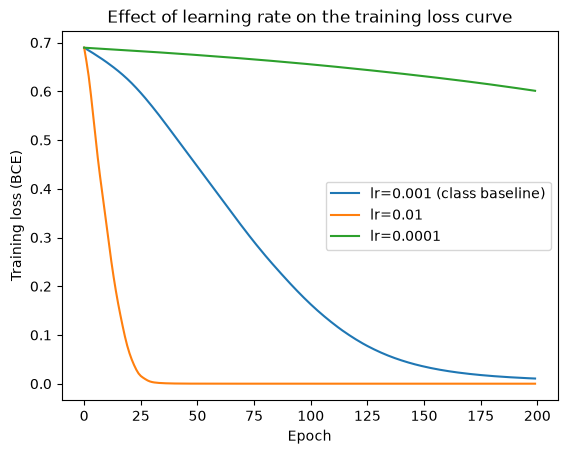

In [6]:
lr_hi_model, lr_hi_losses, lr_hi_acc, _ = train_model(h1=32, h2=16, lr=0.01, n_epochs=200)
lr_lo_model, lr_lo_losses, lr_lo_acc, _ = train_model(h1=32, h2=16, lr=0.0001, n_epochs=200)

print(f"lr=0.001  (class baseline) test accuracy: {baseline_acc:.3f}, final training loss: {baseline_losses[-1]:.4f}")
print(f"lr=0.01   test accuracy: {lr_hi_acc:.3f}, final training loss: {lr_hi_losses[-1]:.4f}")
print(f"lr=0.0001 test accuracy: {lr_lo_acc:.3f}, final training loss: {lr_lo_losses[-1]:.4f}")

plt.plot(baseline_losses, label="lr=0.001 (class baseline)")
plt.plot(lr_hi_losses, label="lr=0.01")
plt.plot(lr_lo_losses, label="lr=0.0001")
plt.xlabel("Epoch")
plt.ylabel("Training loss (BCE)")
plt.title("Effect of learning rate on the training loss curve")
plt.legend()
plt.show()


**My result**: lr=0.001 (class default) reached 0.905 test accuracy with a
final training loss of 0.0106. lr=0.01 also reached 0.905 test accuracy, but
with a final training loss essentially at 0.0000 — it fit the training set
almost perfectly, converging much faster per Part 5's "bigger step, faster
progress" description, without visibly destabilizing training in this case.
lr=0.0001, on the other hand, reached only 0.714 test accuracy with a final
training loss still at 0.6010 after the same 200 epochs — it simply never
got anywhere close to converging in the epoch budget, a direct, concrete
example of Part 5's "too small and training crawls." Together these three
runs bracket the lesson from Part 5 nicely: 0.0001 is clearly too slow for
this budget, 0.001 and 0.01 both work here, with 0.01 converging fastest —
though a learning rate this large is not free of risk in general (it is
easy to imagine it overshooting on a less well-behaved loss surface; it
simply did not happen to on this particular problem).

## Homework 5 — Why `BCEWithLogitsLoss` instead of MAE/RMSE?

*"In your own words, explain why we used `BCEWithLogitsLoss` (binary
cross-entropy) here instead of the MAE/RMSE metrics from `NB07` — what kind
of problem is each one meant for?"*

MAE and RMSE are **regression** losses: they measure the distance between a
predicted real number and a target real number (e.g., predicted vs. actual
fuel consumption in `NB07`), and they treat every unit of error the same way
regardless of where the prediction sits.

Our sonar task is **binary classification**: the target is a class (mine=1,
rock=0), not a continuous quantity, and the network's raw output is a logit
that gets squashed to a 0-1 probability. Binary cross-entropy is built for
exactly this: it penalizes a confident *wrong* prediction (e.g., predicting
0.99 for a true label of 0) far more heavily than an unsure wrong one
(predicting 0.51 for a true label of 0), because it uses a logarithmic
penalty on the predicted probability of the true class. MAE/RMSE would treat
"predicted 0.99, true 0" and "predicted 0.51, true 0" almost the same way
(both are just "off by about 1" or "off by about 0.5" in the raw number),
which throws away exactly the information that matters for a probability:
how confidently wrong the model was. `BCEWithLogitsLoss` also folds the
sigmoid into the loss computation itself, which is more numerically stable
than computing `sigmoid` then a separate cross-entropy by hand — a practical
reason on top of the conceptual one.